<a href="https://colab.research.google.com/github/sborah53/Machine-Learning-for-Physical-Sciences/blob/main/MLPS_FFNN_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feedforward Neural Network as a Variational Approximation to a Quantum Wavefunction

In this notebook we construct a fully explicit feedforward neural network (FFNN) and use it as a variational ansatz to learn a one–dimensional quantum wavefunction from noisy samples. The model is simple enough to be implemented from first principles (NumPy only) but expressive enough to illustrate the universal approximation theorem on a nontrivial oscillatory function.

---

## 1. Function approximation viewpoint

We consider an unknown target function $\Psi_{\text{true}}(x)$ defined on a compact interval, here chosen to mimic a bound quantum state (a damped oscillatory wavefunction). We are given noisy samples
$$
\{(x_i, y_i)\}_{i=1}^m,\quad y_i = \Psi_{\text{true}}(x_i) + \varepsilon_i
$$
and we want to construct a parametric model $\Psi_\theta(x)$ that approximates $\Psi_{\text{true}}(x)$ in the mean–squared sense.

A feedforward neural network with $L$ layers defines a function
$$
a^{[0]} = x,\quad
z^{[l]} = W^{[l]} a^{[l-1]} + b^{[l]},\quad
a^{[l]} = g^{[l]}(z^{[l]}), \quad l=1,\dots,L,
$$
where $W^{[l]}$ and $b^{[l]}$ are trainable parameters and $g^{[l]}$ are elementwise nonlinearities. For scalar input and scalar output we can write $\Psi_\theta(x) = a^{[L]}(x)$ with $\theta = \{W^{[l]},b^{[l]}\}$.

The universal approximation theorem guarantees that, for sufficiently wide hidden layers and suitable nonlinear activations, $\Psi_\theta(x)$ can approximate any continuous function on a compact interval to arbitrary accuracy. In this notebook we choose a 3–layer architecture $[1, 64, 1]$, which is more than sufficient for our 1D regression task.

---

## 2. Architecture and activations

We use ReLU activations in the hidden layers and a linear activation in the output layer:

- Hidden layers:
  $$
  g^{[l]}(z) = \max(0,z) \quad \text{(ReLU)}
  $$
  ReLU introduces nonlinearity while being simple to differentiate and numerically well behaved.

- Output layer:
  $$
  g^{[L]}(z) = z
  $$
  A linear output is natural for real–valued regression targets (here the wavefunction amplitude).

The forward pass can be viewed as a sequence of affine transformations followed by nonlinearities, mapping the 1D input $x$ through a 64–dimensional feature space, then another 64–dimensional representation, and finally back down to a scalar prediction.

---

## 3. Loss functional: MSE as an energy

We train the network by minimizing the empirical mean squared error (MSE) between the predicted amplitudes and the noisy observations:
$$
\mathscr{L}(\theta)
= \frac{1}{2m}\sum_{i=1}^m \left(\Psi_\theta(x_i) - y_i\right)^2.
$$
The factor $1/2$ is convenient because it removes a $2$ in the derivative. In physics language, $\mathscr{L}$ can be interpreted as an effective “energy” or “Hamiltonian” whose minimum corresponds to the best-fitting configuration of parameters.

When the training data are sufficiently dense and the noise is not too large, minimizing MSE drives $\Psi_\theta(x)$ toward the underlying noiseless $\Psi_{\text{true}}(x)$ in an $L^2$ sense.

---

## 4. Backpropagation as discrete calculus of variations

To minimize $\mathscr{L}(\theta)$ with respect to all weights and biases, we apply gradient descent. The key algorithmic ingredient is backpropagation, which systematically applies the chain rule of calculus through the computational graph defined by the network.

For the output layer with linear activation, the derivative of the loss with respect to the pre-activation $z^{[L]}$ is
$$
\delta^{[L]}
= \frac{\partial \mathscr{L}}{\partial z^{[L]}}
= \left(a^{[L]} - y\right) \odot g'^{[L]}(z^{[L]})
= a^{[L]} - y,
$$
since $g'^{[L]}(z)=1$ for a linear output.

For a hidden layer $l$, the error signal (or “adjoint”) propagates backwards as
$$
\delta^{[l]}
= \left( W^{[l+1]\top} \delta^{[l+1]} \right) \odot g'^{[l]}(z^{[l]}),
$$
where $\odot$ denotes elementwise multiplication. For ReLU,
$$
g'^{[l]}(z) = \mathbb{1}\{z > 0\}.
$$

Once we have $\delta^{[l]}$, the gradients of the loss with respect to the parameters are
$$
\frac{\partial \mathscr{L}}{\partial W^{[l]}} = \frac{1}{m}\,\delta^{[l]} a^{[l-1]\top},
\quad
\frac{\partial \mathscr{L}}{\partial b^{[l]}} = \frac{1}{m}\,\sum_{i=1}^m \delta^{[l]}_i,
$$
which are precisely the quantities we compute in the `backward_propagation` method.

Thus backpropagation is a discrete, tensor–valued version of the calculus of variations: it computes how the loss functional changes under infinitesimal variations of each parameter field.

---

## 5. Optimization: gradient descent with He initialization and clipping

We update the parameters by vanilla gradient descent:
$$
W^{[l]} \leftarrow W^{[l]} - \eta \frac{\partial \mathscr{L}}{\partial W^{[l]}}, \quad
b^{[l]} \leftarrow b^{[l]} - \eta \frac{\partial \mathscr{L}}{\partial b^{[l]}},
$$
with learning rate $\eta$.

Two practical considerations ensure stable training:

1. **He initialization**  
   For layers followed by ReLU, we initialize
   $$
   W^{[l]}_{ij} \sim \mathscr{N}\left(0, \frac{2}{n_{\text{in}}}\right),
   $$
   where $n_{\text{in}}$ is the number of inputs to the layer. This preserves variance of activations through depth and mitigates vanishing/exploding activations.

2. **Gradient clipping**  
   Rare large gradients can cause weight updates so big that the network diverges numerically. We control this by clipping the global gradient norm:
   $$
   \text{if } \|\nabla_\theta \mathscr{L}\|_2 > \tau,
   \quad \nabla_\theta \mathscr{L} \leftarrow \tau \frac{\nabla_\theta \mathscr{L}}{\|\nabla_\theta \mathscr{L}\|_2},
   $$
   for some threshold $\tau$. In the code we compute the combined norm of all $dW^{[l]}, db^{[l]}$ and rescale them if necessary.

Together with a suitably small $\eta$, this keeps the optimization in a numerically stable regime where the loss decreases smoothly.

---

## 6. Quantum wavefunction example

As a concrete testbed, we generate synthetic data from a 1D “wavefunction”
$$
\Psi_{\text{true}}(x) = \sin(3x)\,\exp(-0.2 x^2),
$$
evaluated at random points $x \in [-5,5]$ and perturbed by Gaussian noise. This captures two essential features of bound states in a confining potential: oscillations (nodes) and Gaussian–like decay in the tails.

The network sees only the noisy samples $(x_i, y_i)$ and attempts to reconstruct the underlying smooth function $\Psi_{\text{true}}(x)$. After training, we compare:

- The noisy data (scatter),
- The exact $\Psi_{\text{true}}(x)$ used to generate the data (dashed line),
- The learned approximation $\Psi_\theta(x)$ (solid line from the FFNN).

The second plot shows the training loss $\mathscr{L}(\theta_t)$ as a function of epoch, which can be interpreted as a relaxation of the system toward a low–energy configuration in parameter space.

---

This end-to-end construction – from initialization, through forward propagation, loss evaluation, backpropagation, gradient clipping, and visualization – exposes all the mathematical structure underlying modern deep learning while keeping the physical language of energies, wavefunctions, and variational minimization.


Generating Noisy Quantum Wavefunction Data...
Initializing Single-Hidden-Layer MLP (Universal Approximator)...
Beginning Variational Energy Minimization (Backpropagation)...
Epoch     0 | System Energy (MSE Loss): 0.084264
Epoch  1000 | System Energy (MSE Loss): 0.113340
Epoch  2000 | System Energy (MSE Loss): 0.086386
Epoch  3000 | System Energy (MSE Loss): 0.040154
Epoch  4000 | System Energy (MSE Loss): 0.051607
Epoch  5000 | System Energy (MSE Loss): 0.044634
Epoch  6000 | System Energy (MSE Loss): 0.041822
Epoch  7000 | System Energy (MSE Loss): 0.040933
Epoch  8000 | System Energy (MSE Loss): 0.040364
Epoch  9000 | System Energy (MSE Loss): 0.039583
Epoch 10000 | System Energy (MSE Loss): 0.039085
Epoch 11000 | System Energy (MSE Loss): 0.038759
Epoch 12000 | System Energy (MSE Loss): 0.038464
Epoch 13000 | System Energy (MSE Loss): 0.038114
Epoch 14000 | System Energy (MSE Loss): 0.037933
Epoch 15000 | System Energy (MSE Loss): 0.037601
Epoch 16000 | System Energy (MSE Loss): 0.

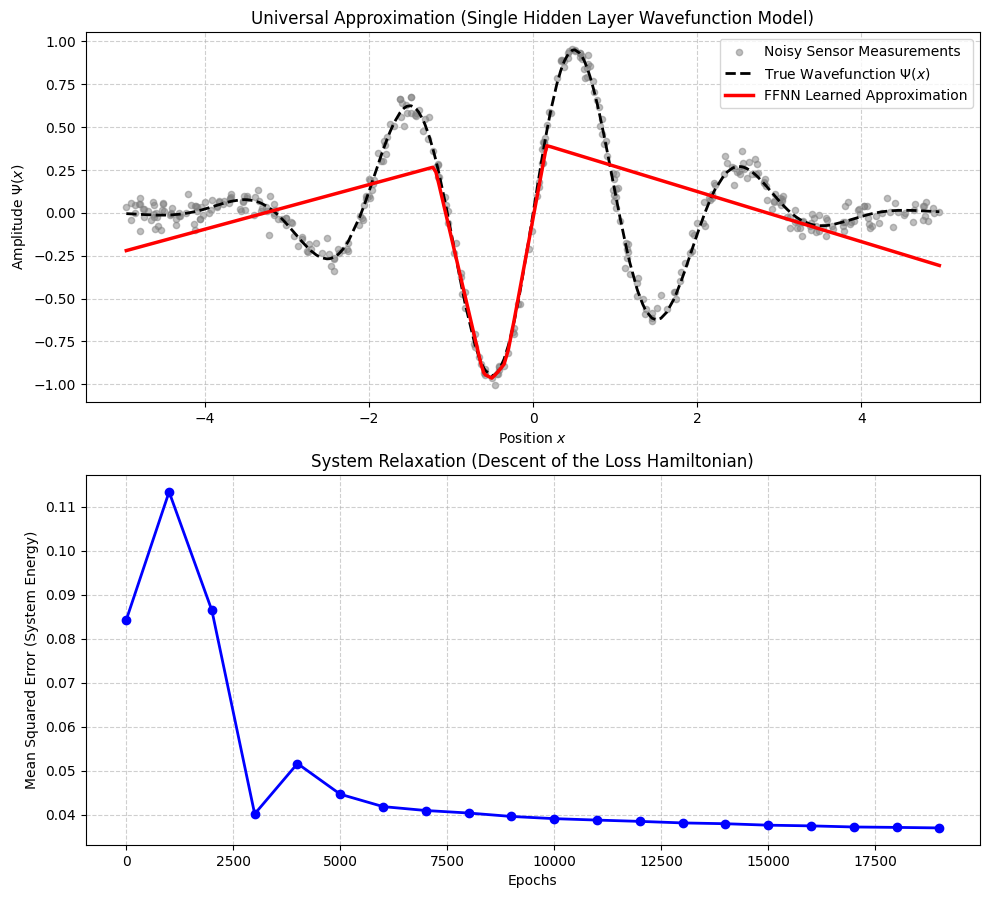

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# =====================================================================
# CORE IMPLEMENTATION: FEEDFORWARD NEURAL NETWORK FROM SCRATCH
# =====================================================================


class Relu:
    """Rectified Linear Unit Activation (Symmetry Breaking)"""
    @staticmethod
    def forward(Z):
        return np.maximum(0, Z)

    @staticmethod
    def backward(Z):
        return (Z > 0).astype(float)


class Linear:
    """Linear Activation (For continuous regression outputs)"""
    @staticmethod
    def forward(Z):
        return Z

    @staticmethod
    def backward(Z):
        return np.ones_like(Z)



class FFNNPhysics:
    """
    A multi-layer feedforward neural network implemented via fundamental
    tensor calculus and backpropagation principles.
    """
    def __init__(self, layer_dims, learning_rate=0.01, epochs=10000):
        """
        layer_dims: list containing the number of nodes in each layer.
                    e.g., [1, 128, 1] for a 1D regression mapping with
                    a single hidden layer.
        """
        self.layer_dims = layer_dims
        self.lr = learning_rate
        self.epochs = epochs
        self.L = len(layer_dims) - 1  # Number of active mapping layers

        self.W = {}
        self.b = {}

        # 1. Initialization (He Initialization)
        np.random.seed(42)
        for l in range(1, self.L + 1):
            self.W[l] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2.0 / layer_dims[l-1])
            self.b[l] = np.zeros((layer_dims[l], 1))

    def forward_propagation(self, X):
        """Vectorized Kinematics (Eq: Z = W A + b)"""
        self.A = {0: X}
        self.Z = {}

        # Hidden layers: ReLU
        for l in range(1, self.L):
            self.Z[l] = np.dot(self.W[l], self.A[l-1]) + self.b[l]
            self.A[l] = Relu.forward(self.Z[l])

        # Output layer: Linear activation for continuous regression
        self.Z[self.L] = np.dot(self.W[self.L], self.A[self.L-1]) + self.b[self.L]
        self.A[self.L] = Linear.forward(self.Z[self.L])

        return self.A[self.L]

    def compute_cost(self, Y_pred, Y_true):
        """Mean Squared Error (Hamiltonian / Elastic Potential)"""
        m = Y_true.shape[1]
        diff = Y_pred - Y_true
        cost = (1.0 / (2 * m)) * np.sum(diff * diff)
        return cost

    def backward_propagation(self, Y_true):
        """Calculus of Variations: Backpropagating the error tensor delta."""
        m = Y_true.shape[1]
        self.dW = {}
        self.db = {}
        delta = {}

        # 1. Output Layer Error (Derivative of MSE with Linear activation)
        delta[self.L] = (self.A[self.L] - Y_true) * Linear.backward(self.Z[self.L])
        self.dW[self.L] = (1.0 / m) * np.dot(delta[self.L], self.A[self.L-1].T)
        self.db[self.L] = (1.0 / m) * np.sum(delta[self.L], axis=1, keepdims=True)

        # 2. Hidden Layer Error Propagation (Reverse Kinematics)
        for l in reversed(range(1, self.L)):
            da_dl = np.dot(self.W[l+1].T, delta[l+1])
            delta[l] = da_dl * Relu.backward(self.Z[l])

            self.dW[l] = (1.0 / m) * np.dot(delta[l], self.A[l-1].T)
            self.db[l] = (1.0 / m) * np.sum(delta[l], axis=1, keepdims=True)

    def clip_gradients(self, max_norm=1.0):
        """Global gradient norm clipping to prevent explosions."""
        total_norm = 0.0
        for l in range(1, self.L + 1):
            total_norm += np.sum(self.dW[l] ** 2) + np.sum(self.db[l] ** 2)
        total_norm = np.sqrt(total_norm)

        if total_norm > max_norm:
            scale = max_norm / (total_norm + 1e-8)
            for l in range(1, self.L + 1):
                self.dW[l] *= scale
                self.db[l] *= scale

    def update_parameters(self):
        """Gradient Descent Step"""
        for l in range(1, self.L + 1):
            self.W[l] -= self.lr * self.dW[l]
            self.b[l] -= self.lr * self.db[l]

    def fit(self, X, Y):
        """Orchestrates the training loop."""
        costs = []
        for i in range(self.epochs):
            Y_pred = self.forward_propagation(X)
            cost = self.compute_cost(Y_pred, Y)

            # NaN/Inf guard (optional, for debugging)
            if not np.isfinite(cost):
                print(f"Numerical issue at epoch {i}, cost={cost}. Stopping.")
                break

            self.backward_propagation(Y)
            self.clip_gradients(max_norm=1.0)
            self.update_parameters()

            if i % 1000 == 0:
                costs.append(cost)
                print(f"Epoch {i:5d} | System Energy (MSE Loss): {cost:.6f}")
        return costs



# =====================================================================
# PHYSICS APPLICATION: LEARNING A QUANTUM WAVEFUNCTION
# =====================================================================



def generate_wavefunction_data(n_samples=400):
    """
    Simulates the probability amplitude / wavefunction of a quantum harmonic
    oscillator state (a highly non-linear, oscillating 1D function).
    True Psi(x) = sin(3x) * exp(-0.2 * x^2)
    """
    np.random.seed(10)
    # Generate X uniformly between -5 and 5
    X_raw = np.sort(np.random.uniform(-5, 5, n_samples))

    # Optional: standardize inputs to improve conditioning
    X_mean = np.mean(X_raw)
    X_std = np.std(X_raw)
    X = (X_raw - X_mean) / X_std

    # True underlying physical law
    Y_true = np.sin(3 * X_raw) * np.exp(-0.2 * X_raw**2)
    # Add experimental measurement noise
    Y_noisy = Y_true + np.random.normal(0, 0.05, n_samples)

    # Reshape for Neural Network (features x samples)
    X = X.reshape(1, n_samples)
    Y_noisy = Y_noisy.reshape(1, n_samples)
    Y_true = Y_true.reshape(1, n_samples)

    return X, Y_noisy, Y_true, X_raw



if __name__ == "__main__":
    print("Generating Noisy Quantum Wavefunction Data...")
    X_train, Y_train_noisy, Y_true, X_raw = generate_wavefunction_data()

    # 1. Network Architecture (1 Input -> 128 Hidden -> 1 Output)
    print("Initializing Single-Hidden-Layer MLP (Universal Approximator)...")
    architecture = [1, 64, 1]  # single hidden layer
    model = FFNNPhysics(layer_dims=architecture, learning_rate=0.1, epochs=20000)

    # 2. Train the network
    print("Beginning Variational Energy Minimization (Backpropagation)...")
    loss_history = model.fit(X_train, Y_train_noisy)

    print("Finished traninig. Evaluating ...")
    print("\n")

    # 3. Predict the continuous surface
    Y_pred = model.forward_propagation(X_train)

    # 4. Visualization
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    # Plot 1: The Function Approximation
    # Use X_raw (physical coordinate) for plotting
    axes[0].scatter(X_raw, Y_train_noisy[0], color='gray', alpha=0.5, s=20,
                    label='Noisy Sensor Measurements')
    axes[0].plot(X_raw, Y_true[0], 'k--', lw=2, label=r'True Wavefunction $\Psi(x)$')
    axes[0].plot(X_raw, Y_pred[0], 'r-', lw=2.5, label='FFNN Learned Approximation')
    axes[0].set_title("Universal Approximation (Single Hidden Layer Wavefunction Model)")
    axes[0].set_xlabel(r"Position $x$")
    axes[0].set_ylabel(r"Amplitude $\Psi(x)$")
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Thermodynamic Energy Decay (Loss)
    epochs_sampled = np.arange(0, len(loss_history) * 1000, 1000)
    axes[1].plot(epochs_sampled, loss_history, 'b-', lw=2, marker='o')
    axes[1].set_title("System Relaxation (Descent of the Loss Hamiltonian)")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Mean Squared Error (System Energy)")
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()
